In [ ]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader , random_split
from torchvision import datasets,transforms
import torch
from torch import nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import InterpolationMode
from sklearn.metrics import confusion_matrix , accuracy_score
from tqdm.auto import tqdm
from timeit import default_timer as timer
from pathlib import Path
from torchvision import models


In [ ]:
os.environ["KAGGLE_USERNAME"] = "hunaintahir"
os.environ["KAGGLE_KEY"] = "KGAT_d82be1c158b13a59542aac63a4b85f79"


In [ ]:
!kaggle datasets list -s "vehicle detection"

ref                                                                  title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
dataturks/vehicle-number-plate-detection                             Vehicle Number Plate Detection                            20295  2018-07-13 11:29:47.607000          18202        272  0.75             
brsdincer/vehicle-detection-image-set                                Vehicle Detection Image Set                           125013111  2021-05-09 17:54:02.263000          13852        160  0.875            
pkdarabi/vehicle-detection-image-dataset                             Vehicle Detection Image Dataset                       274761684  2024-04-09 12:47:23.663000           5738 

In [ ]:
!kaggle datasets download -d kaggleashwin/vehicle-type-recognition

Dataset URL: https://www.kaggle.com/datasets/kaggleashwin/vehicle-type-recognition
License(s): apache-2.0
vehicle-type-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip vehicle-type-recognition.zip -d vehicle_cnn



Archive:  vehicle-type-recognition.zip
replace vehicle_cnn/Dataset/Bus/Image_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
len(os.listdir("vehicle_cnn/Dataset/Car"))

100

In [ ]:
for dir,dir_names , filenames in os.walk("vehicle_cnn/Dataset"):
 print(f"There are {len(dir_names)} directories with {len(filenames)} files in {dir} folder")

There are 4 directories with 0 files in vehicle_cnn/Dataset folder
There are 0 directories with 100 files in vehicle_cnn/Dataset/motorcycle folder
There are 0 directories with 100 files in vehicle_cnn/Dataset/Car folder
There are 0 directories with 100 files in vehicle_cnn/Dataset/Bus folder
There are 0 directories with 100 files in vehicle_cnn/Dataset/Truck folder


In [ ]:
# classes
classes = os.listdir("vehicle_cnn/Dataset")
print(classes)

['motorcycle', 'Car', 'Bus', 'Truck']


In [ ]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
]
)
test_transform  = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [ ]:
# spitting data by split folders
!pip install split-folders

In [ ]:
import splitfolders
splitfolders.ratio("vehicle_cnn/Dataset" , output="vehicle_split", seed = 42 ,ratio=( 0.8,0.2))

Copying files: 400 files [00:00, 793.53 files/s]


In [ ]:
len(os.listdir("vehicle_split/train/Bus")), len(os.listdir("vehicle_split/val/Car"))

(80, 20)

In [ ]:
# datafolder
train_data = datasets.ImageFolder(root="vehicle_split/train" , transform= train_transform)
test_data = datasets.ImageFolder(root="vehicle_split/val" , transform= test_transform)

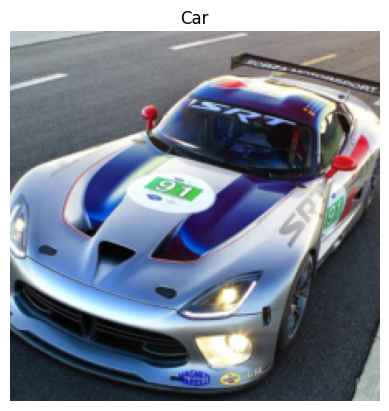

In [ ]:
img ,lab = random.choice(train_data)
std = torch.tensor([0.229, 0.224, 0.225])
mean = torch.tensor([0.485, 0.456, 0.406])
img=img.permute(1,2,0)
img = std * img + mean
plt.title(train_data.classes[lab])
plt.axis("off")
plt.imshow(img)

In [ ]:
print(train_data.classes)
print(train_data.class_to_idx)

['Bus', 'Car', 'Truck', 'motorcycle']
{'Bus': 0, 'Car': 1, 'Truck': 2, 'motorcycle': 3}


In [ ]:
len(train_data)  , len(test_data)

(320, 80)

In [ ]:
print(os.path.exists("vehicle_split/train"))
print(os.path.exists("vehicle_split/val"))

True
True


In [ ]:
train_dataloader = DataLoader(train_data , batch_size=32 , shuffle=True)
test_dataloader = DataLoader(test_data , batch_size=32 , shuffle=False)

In [ ]:
# model
class vehicle(nn.Module):
  def __init__(self):
    super().__init__()
    self.blok1= nn.Sequential(
        nn.Conv2d(3,128 , kernel_size=3, padding=1, stride=1),
        nn.ReLU(),
        nn.Conv2d(128 , 256, kernel_size=3, stride=1 , padding =1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.blok2= nn.Sequential(
        nn.Conv2d(256 , 256, kernel_size=3, stride=1 , padding =1 ),
        nn.ReLU(),
        nn.Conv2d(256 ,128 , kernel_size=3 , stride=1 , padding =1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 *56 *56, 4  )

    )
  def forward(self ,x):
      x=self.blok1(x)
      x=self.blok2(x)
      x=self.classifier(x)
      return x

In [ ]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
!nvidia-smi

Thu Mar 19 03:34:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(vehicle() , input_size=(32,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
vehicle                                  [32, 4]                   --
├─Sequential: 1-1                        [32, 256, 112, 112]       --
│    └─Conv2d: 2-1                       [32, 128, 224, 224]       3,584
│    └─ReLU: 2-2                         [32, 128, 224, 224]       --
│    └─Conv2d: 2-3                       [32, 256, 224, 224]       295,168
│    └─ReLU: 2-4                         [32, 256, 224, 224]       --
│    └─MaxPool2d: 2-5                    [32, 256, 112, 112]       --
├─Sequential: 1-2                        [32, 128, 56, 56]         --
│    └─Conv2d: 2-6                       [32, 256, 112, 112]       590,080
│    └─ReLU: 2-7                         [32, 256, 112, 112]       --
│    └─Conv2d: 2-8                       [32, 128, 112, 112]       295,040
│    └─ReLU: 2-9                         [32, 128, 112, 112]       --
│    └─MaxPool2d: 2-10                   [32, 128, 56, 56]         

In [ ]:
model = vehicle().to(device)
img  , lab = train_data[0]
print(img.shape)
img=img.unsqueeze(0).to(device)
print(img.shape)
model(img)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


tensor([[0.0280, 0.0104, 0.0278, 0.0122]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters() , lr = 0.001)

In [ ]:
def train_step(model , dataload , loss_fn , optimizer , device):
  model.train()
  train_loss , train_acc = 0,0
  for batch , (X,y) in enumerate(dataload):
    X= X.to(device)
    y=y.to(device)
    y_pred = model(X)
    loss= loss_fn(y_pred , y)
    train_loss += loss.item()
    acc = accuracy_score( y.cpu(), torch.argmax(torch.softmax(y_pred.cpu(), dim=1), dim=1) )
    train_acc += acc
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss= train_loss /len(dataload)
  train_acc= train_acc /len(dataload)
  return train_loss , train_acc



In [ ]:
def test_step(model, dataload , loss_fn , device):
  model.eval()
  test_loss, test_acc = 0 , 0
  with torch.inference_mode():
    for batch , (X,y) in enumerate(dataload):
      X= X.to(device)
      y=y.to(device)
      test_pred= model(X)
      loss = loss_fn(test_pred, y )
      test_loss+= loss.item()
      acc= accuracy_score( y.cpu() , torch.argmax(torch.softmax(test_pred.cpu(), dim=1 ), dim=1 ))
      test_acc += acc
    test_loss = test_loss / len(dataload)
    test_acc = test_acc / len(dataload)
    return test_loss , test_acc



In [ ]:
def training(model , train_dataload , test_dataload , optimizer , loss_fn , epochs , device):
  results = {
      "train_loss" :[] ,
      "train_acc"  :[] ,
      "test_loss"  :[] ,
      "test_acc"   :[]
  }
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model , train_dataload ,loss_fn , optimizer , device )
    test_loss , test_acc = test_step(model , test_dataload , loss_fn , device)
    print(f"epoch {epoch+1} | train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | test_loss {test_loss:.4f} | test_acc {test_acc:.4f}")
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
  return results


In [ ]:
start = timer()
res_mod=training(model , train_dataloader , test_dataloader , optimizer , loss_fn , 10 , device)
end = timer()
print(end - start)

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1 | train_loss 4.3501 | train_acc 0.2781 | test_loss 1.4347 | test_acc 0.2083


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2 | train_loss 1.3581 | train_acc 0.3906 | test_loss 1.2377 | test_acc 0.4479


...

epoch 8 | train_loss 0.6802 | train_acc 0.7281 | test_loss 1.4640 | test_acc 0.5208


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 9 | train_loss 0.4979 | train_acc 0.8031 | test_loss 1.3697 | test_acc 0.5833


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 10 | train_loss 0.4703 | train_acc 0.8375 | test_loss 1.7790 | test_acc 0.5625
170.97324322699933


In [ ]:
def plot_loss_curves(results):
    epochs = range(len(results["train_loss"]))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, results["train_loss"], label="train_loss")
    ax1.plot(epochs, results["test_loss"],  label="test_loss")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, results["train_acc"], label="train_acc")
    ax2.plot(epochs, results["test_acc"],  label="test_acc")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()


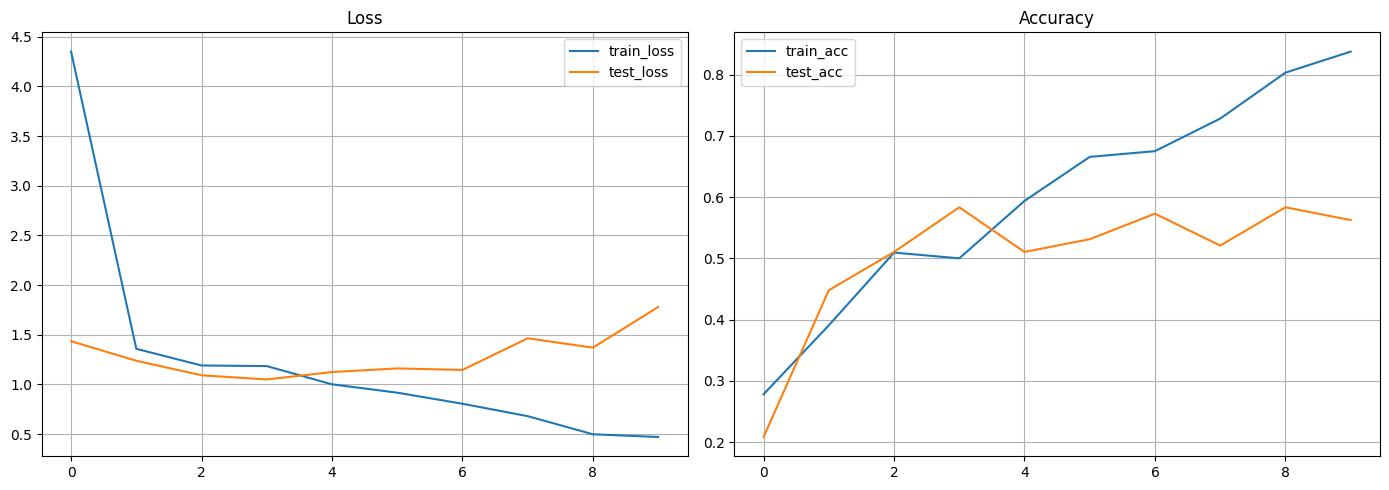

In [ ]:
plot_loss_curves(res_mod)

The model from scratch is failed due to small number of images in the dataset


*  Train accuracy  (0.83) 83 %
*  Test accuracy   (0.56) 55 %

  

*   So the model is overfitting
*   Now we use the transfer learning to train the model to cheak the model performance










In [ ]:
# setting up model
weight = models.EfficientNet_B0_Weights.DEFAULT
model_1 = models.efficientnet_b0(weights=weight)

In [ ]:
# freezing the feature extraction layers
for param in model_1.features.parameters():
  param.requires_grad=False

In [ ]:
# Transformation For the Transfer model
train_transforms = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2 , 0.2 ,0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),
     transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# creating thw image foldder for required transforms
train_data = datasets.ImageFolder(root = "vehicle_split/train" , transform= train_transforms )
test_data = datasets.ImageFolder(root ="vehicle_split/val", transform=test_transforms )

In [ ]:
len(train_data) , len(test_data)

(320, 80)

In [ ]:
model_1.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features=1280,
              out_features=4)
)

In [ ]:
model_1.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)

In [ ]:
model_1 =model_1.to(device)

In [ ]:
# setting up Dataloader
train_dataloader = DataLoader(train_data , batch_size=32 , shuffle=True)
test_dataloader = DataLoader(test_data , batch_size=32 , shuffle=False)

In [ ]:
# setting up loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.classifier.parameters(), lr = 0.001)

In [ ]:
res_mod1=training(model_1,train_dataloader , test_dataloader , optimizer , loss_fn , 5 , device )

  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1 | train_loss 1.2458 | train_acc 0.4594 | test_loss 1.0323 | test_acc 0.7917


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2 | train_loss 0.9517 | train_acc 0.7656 | test_loss 0.7727 | test_acc 0.8542


...

epoch 3 | train_loss 0.7645 | train_acc 0.8250 | test_loss 0.6242 | test_acc 0.8438


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 4 | train_loss 0.6157 | train_acc 0.8656 | test_loss 0.5528 | test_acc 0.8750


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 5 | train_loss 0.5472 | train_acc 0.8906 | test_loss 0.4974 | test_acc 0.8750


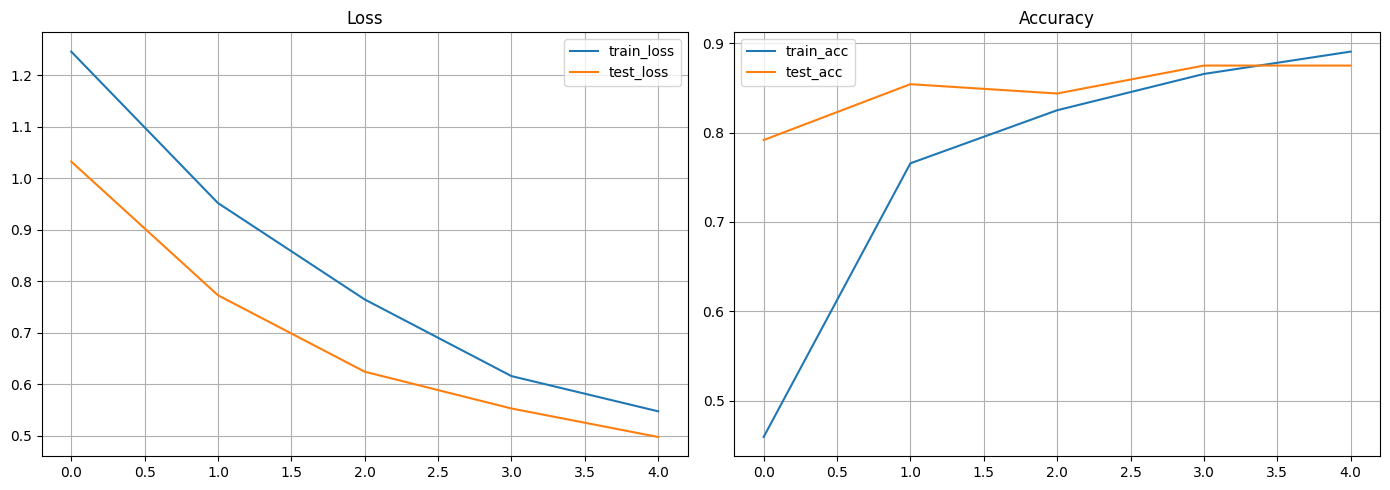

In [ ]:
plot_loss_curves(res_mod1)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
yolo_model = YOLO("yolov8n.pt")
all_images = list(Path("vehicle_split/val").glob("*/*.jpg")) + \
             list(Path("vehicle_split/val").glob("*/*.JPG")) + \
             list(Path("vehicle_split/val").glob("*/*.png")) + \
             list(Path("vehicle_split/val").glob("*/*.PNG")) + \
             list(Path("vehicle_split/val").glob("*/*.jpeg"))





0: 640x640 1 bus, 5.4ms
1: 640x640 1 motorcycle, 5.4ms
2: 640x640 1 car, 1 bus, 1 truck, 5.4ms
3: 640x640 (no detections), 5.4ms
4: 640x640 1 truck, 5.4ms
5: 640x640 (no detections), 5.4ms
6: 640x640 (no detections), 5.4ms
7: 640x640 1 bus, 5.4ms
8: 640x640 1 car, 5.4ms
9: 640x640 1 car, 5.4ms
Speed: 2.3ms preprocess, 5.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
random_images = random.sample(all_images, 10)
result = yolo_model.predict(source=random_images,classes=[0,2, 3, 5, 7], conf=0.5)


0: 640x640 1 car, 5.4ms
1: 640x640 1 bus, 5.4ms
2: 640x640 1 motorcycle, 5.4ms
3: 640x640 1 bus, 5.4ms
4: 640x640 1 truck, 5.4ms
5: 640x640 1 motorcycle, 5.4ms
6: 640x640 1 motorcycle, 5.4ms
7: 640x640 1 car, 5.4ms
8: 640x640 1 truck, 5.4ms
9: 640x640 (no detections), 5.4ms
Speed: 2.5ms preprocess, 5.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
for r in result[:10]:
    r.show()

Saving images (2).jpg to images (2).jpg

image 1/1 /content/images (2).jpg: 448x640 7 persons, 1 bus, 10.5ms
Speed: 2.8ms preprocess, 10.5ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)


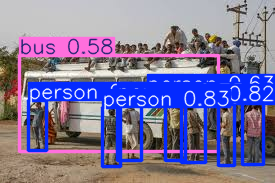

In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

result = yolo_model.predict(
    source=image_path,
    conf=0.5
)

result[0].show()